# Week 2

## Demo

Depending on your knowledge of R, getting an overview of the data we imported last week might have been quite a challenge. Surprisingly enough, **importing, cleaning and exploring your data** can be the most challenging, time consuming part of a project. RStudio and the tidyverse offer many helpful tools to make this part easier (and more fun). You have read chapters on `dplyr` and `magrittr` as a preparation for this exercise. Before we start with the exercise however, this demo illustrates a simple approach offered by tidyverse which is applicable to sf-objects.

Assume we want to calculate the timelag between subsequent positions. To achieve this we can use the function `difftime()` combined with `lead()` from `dplyr`. Let’s look at these functions one by one.

### `difftime()`
`difftime` takes **two POSIXct values (t1, t2)**.

In [1]:
now <- as.POSIXct("2024-04-26 10:20:00")
later <- as.POSIXct("2024-04-26 11:35:00")

later

[1] "2024-04-26 11:35:00 CEST"

In [2]:
time_difference <- difftime(later, now)

time_difference

Time difference of 1.25 hours

#### Specify the unit of the output

In [3]:
time_difference <- difftime(later, now, units = "secs")

time_difference

Time difference of 4500 secs

`difftime` returns an object of the class *difftime*.

In [4]:
class(time_difference)

[1] "difftime"

In [5]:
str(time_difference)

 'difftime' num 4500
 - attr(*, "units")= chr "secs"


However in our case, **numeric values** would be more handy than the class difftime. So we’ll wrap the command in `as.numeric()`:

In [6]:
time_difference <- as.numeric(difftime(later, now, units = "secs"))

In [7]:
time_difference

str(time_difference)

class(time_difference)

[1] 4500

 num 4500


[1] "numeric"

#### Create a function
In fact, we will use this exact operation multiple times, so let’s create a function for this:

In [8]:
difftime_secs <- function(later, now){
    as.numeric(difftime(later, now, units = "secs"))
}

### `lead()` / `lag()`

`lead()` and `lag()` return **a vector of the same length as the input**, just **offset by a specific number of values** (default is 1). 

- **`lead()`** ersetzt die erste(n) Zahl(en) durch `NA` --> schiebt die NA nach hinten
- **`lag()`** ersetzt die letzte(n) Zahl(en) durch `NA` --> schiebt die NA nach vorne
- `n =` definiert: wie viele Zahlen sollen ersetzt werden
- `default =` definiert: durch was sollen sie ersetzt werden


Consider the following sequence:

In [9]:
numbers <- 1:10

numbers

[1]  1  2  3  4  5  6  7  8  9 10

We can now run `lead()` and `lag()` on this sequence to illustrate the output. **`n =` specifies the offset, `default =` specifies the default value used to “fill” the emerging “empty spaces” of the vector.** This helps us performing operations on subsequent values in a vector (or rows in a table).

In [10]:
library("dplyr")

lead(numbers)


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union




[1]  2  3  4  5  6  7  8  9 10 NA

In [11]:
lead(numbers, n = 2)

[1]  3  4  5  6  7  8  9 10 NA NA

In [12]:
lag(numbers)

[1] NA  1  2  3  4  5  6  7  8  9

In [13]:
lag(numbers, n = 5)

[1] NA NA NA NA NA  1  2  3  4  5

In [14]:
lag(numbers, n = 5, default = 0)

[1] 0 0 0 0 0 1 2 3 4 5

In [15]:
lag(numbers, n = 5, default = 55)

[1] 55 55 55 55 55  1  2  3  4  5

### mutate()
Using the above functions (difftime() and lead()), we can calculate the **time lag**, that is, the **time difference between consecutive positions**. We will try this on a dummy version of our wild boar dataset.

In [16]:
wildschwein <- tibble(       # aka data.frame
    TierID = rep(c("Hans", "Klara"), each = 5),
    DatetimeUTC = rep(as.POSIXct("2015-01-01 00:00:00", tz = "UTC") + 0:4 * 15 * 60, 2)
)

wildschwein

TierID,DatetimeUTC
<chr>,<dttm>
Hans,2015-01-01 00:00:00
Hans,2015-01-01 00:15:00
Hans,2015-01-01 00:30:00
Hans,2015-01-01 00:45:00
Hans,2015-01-01 01:00:00
Klara,2015-01-01 00:00:00
Klara,2015-01-01 00:15:00
Klara,2015-01-01 00:30:00
Klara,2015-01-01 00:45:00


#### Calculare speed
If we are interested to calculate the **speed travelled between subsequent locations**, we need to calculate the **elapsed time first**. Since R does most operations in a vectorized manner, we can use our **function `difftime_secs`** on the entire column DatetimeUTC of our dataframe wildschwein and store the output in a new column.

--> Damit habe ich im Vektor `now` die Zeit unverändert, aber im Vektor `later` schiebe ich alles einen Timestep weiter, sodass ich damit rechnen kann (Position 1 - Position 1, etc.)

In [17]:
now <- wildschwein$DatetimeUTC
later <- lead(now)

In [18]:
now

 [1] "2015-01-01 00:00:00 UTC" "2015-01-01 00:15:00 UTC"
 [3] "2015-01-01 00:30:00 UTC" "2015-01-01 00:45:00 UTC"
 [5] "2015-01-01 01:00:00 UTC" "2015-01-01 00:00:00 UTC"
 [7] "2015-01-01 00:15:00 UTC" "2015-01-01 00:30:00 UTC"
 [9] "2015-01-01 00:45:00 UTC" "2015-01-01 01:00:00 UTC"

In [19]:
later

 [1] "2015-01-01 00:15:00 UTC" "2015-01-01 00:30:00 UTC"
 [3] "2015-01-01 00:45:00 UTC" "2015-01-01 01:00:00 UTC"
 [5] "2015-01-01 00:00:00 UTC" "2015-01-01 00:15:00 UTC"
 [7] "2015-01-01 00:30:00 UTC" "2015-01-01 00:45:00 UTC"
 [9] "2015-01-01 01:00:00 UTC" NA                       

In [20]:
difftime_secs

function (later, now) 
{
    as.numeric(difftime(later, now, units = "secs"))
}

In [21]:
# View(wildschwein)

wildschwein$timelag <- difftime_secs(later, now)

wildschwein

TierID,DatetimeUTC,timelag
<chr>,<dttm>,<dbl>
Hans,2015-01-01 00:00:00,900
Hans,2015-01-01 00:15:00,900
Hans,2015-01-01 00:30:00,900
Hans,2015-01-01 00:45:00,900
Hans,2015-01-01 01:00:00,-3600
Klara,2015-01-01 00:00:00,900
Klara,2015-01-01 00:15:00,900
Klara,2015-01-01 00:30:00,900
Klara,2015-01-01 00:45:00,900


However, we have an issue at the transition between the two animals. We can overcome this issue using dplyr’s `mutate` with `group_by`. If we use mutate, we do not use the $ notation!

In [22]:
# note the lack of "$"
wildschwein <- mutate(wildschwein, 
                      timelag = difftime_secs(lead(DatetimeUTC), DatetimeUTC))

wildschwein

TierID,DatetimeUTC,timelag
<chr>,<dttm>,<dbl>
Hans,2015-01-01 00:00:00,900
Hans,2015-01-01 00:15:00,900
Hans,2015-01-01 00:30:00,900
Hans,2015-01-01 00:45:00,900
Hans,2015-01-01 01:00:00,-3600
Klara,2015-01-01 00:00:00,900
Klara,2015-01-01 00:15:00,900
Klara,2015-01-01 00:30:00,900
Klara,2015-01-01 00:45:00,900


The output is equivalent, we need `group_by` as well.

### `group_by()`
To distinguish groups in a dataframe, we need to specify these using `group_by()`.

In [23]:
# again, note the lack of "$"
wildschwein <- group_by(wildschwein, TierID)
wildschwein

TierID,DatetimeUTC,timelag
<chr>,<dttm>,<dbl>
Hans,2015-01-01 00:00:00,900
Hans,2015-01-01 00:15:00,900
Hans,2015-01-01 00:30:00,900
Hans,2015-01-01 00:45:00,900
Hans,2015-01-01 01:00:00,-3600
Klara,2015-01-01 00:00:00,900
Klara,2015-01-01 00:15:00,900
Klara,2015-01-01 00:30:00,900
Klara,2015-01-01 00:45:00,900


After adding this grouping variable, calculating the timelag automatically accounts for the individual trajectories.

In [24]:
# again, note the lack of "$"
wildschwein <- mutate(wildschwein, timelag = difftime_secs(lead(DatetimeUTC), DatetimeUTC))

wildschwein

TierID,DatetimeUTC,timelag
<chr>,<dttm>,<dbl>
Hans,2015-01-01 00:00:00,900
Hans,2015-01-01 00:15:00,900
Hans,2015-01-01 00:30:00,900
Hans,2015-01-01 00:45:00,900
Hans,2015-01-01 01:00:00,NA
Klara,2015-01-01 00:00:00,900
Klara,2015-01-01 00:15:00,900
Klara,2015-01-01 00:30:00,900
Klara,2015-01-01 00:45:00,900


### Piping
Piping can simplify the process and help us write our sequence of operations in a manner as we would explain them to another human being.

In order to make code readable in a more human-friendly way, we can use the piping command (|> or %>%, it does not matter which).

In [25]:
wildschwein %>%                                                    # Take wildschwein...
    group_by(TierID) %>%                                           # ...group it by TierID
    mutate(
        timelag = difftime_secs(lead(DatetimeUTC), DatetimeUTC)    # Caculate difftime
        )

TierID,DatetimeUTC,timelag
<chr>,<dttm>,<dbl>
Hans,2015-01-01 00:00:00,900
Hans,2015-01-01 00:15:00,900
Hans,2015-01-01 00:30:00,900
Hans,2015-01-01 00:45:00,900
Hans,2015-01-01 01:00:00,NA
Klara,2015-01-01 00:00:00,900
Klara,2015-01-01 00:15:00,900
Klara,2015-01-01 00:30:00,900
Klara,2015-01-01 00:45:00,900


### `summarise()`
If we want to summarise our data and get metrics per animal, we can use the dplyr function `summarise()`. In contrast to `mutate()`, which just adds a new column to the dataset, `summarise()` “collapses” the data to one row per individual (specified by group_by).

In [26]:
summarise(wildschwein, mean = mean(timelag, na.rm = TRUE))

TierID,mean
<chr>,<dbl>
Hans,900
Klara,900


## Exercise A

### Import Data

Note:

- that this dataset is already converted to **EPSG 2056**
- the **coordinates** are stored in the columns `(E/N)`

In [27]:
library("readr")
library("sf")

wildschwein_BE <- read_delim("Data/wildschwein_BE_2056.csv", ",")

wildschwein_BE <- st_as_sf(wildschwein_BE, coords = c("E", "N"), crs = 2056)

Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [28]:
head(wildschwein_BE)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



TierID,TierName,CollarID,DatetimeUTC,geometry
<chr>,<chr>,<dbl>,<dttm>,<POINT [m]>
002A,Sabi,12275,2014-08-22 21:00:12,POINT (2570409 1204752)
002A,Sabi,12275,2014-08-22 21:15:16,POINT (2570402 1204863)
002A,Sabi,12275,2014-08-22 21:30:43,POINT (2570394 1204826)
002A,Sabi,12275,2014-08-22 21:46:07,POINT (2570379 1204817)
002A,Sabi,12275,2014-08-22 22:00:22,POINT (2570390 1204818)
002A,Sabi,12275,2014-08-22 22:15:10,POINT (2570390 1204825)


In [29]:
str(wildschwein_BE)

sf [51,246 × 5] (S3: sf/tbl_df/tbl/data.frame)
 $ TierID     : chr [1:51246] "002A" "002A" "002A" "002A" ...
 $ TierName   : chr [1:51246] "Sabi" "Sabi" "Sabi" "Sabi" ...
 $ CollarID   : num [1:51246] 12275 12275 12275 12275 12275 ...
 $ DatetimeUTC: POSIXct[1:51246], format: "2014-08-22 21:00:12" "2014-08-22 21:15:16" ...
 $ geometry   :sfc_POINT of length 51246; first list element:  'XY' num [1:2] 2570409 1204752
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA
  ..- attr(*, "names")= chr [1:4] "TierID" "TierName" "CollarID" "DatetimeUTC"


### Calculate time difference
Calculate the time difference between subsequent rows as described in the demo. You can calculate the time difference using the function `difftime_secs()` (see below) in combination with `lead()`. Store the time difference in a new column (e.g. timelag).

**Important:** `summarise()` tries to coerce all (Point-) geometries into one object, which can take along time. To avoid this, use `st_drop_geometry()` before using `summarise()`.

In [30]:
difftime_secs <- function(later, now){
    as.numeric(difftime(later, now, units = "secs"))
}

In [31]:
wildschwein_BE <- wildschwein_BE %>%     
    group_by(TierID) %>%                                           # ...group it by TierID
    mutate(
        timelag = difftime_secs(lead(DatetimeUTC), DatetimeUTC)    # Caculate difftime
        )

In [32]:
head(wildschwein_BE)

TierID,TierName,CollarID,DatetimeUTC,geometry,timelag
<chr>,<chr>,<dbl>,<dttm>,<POINT [m]>,<dbl>
002A,Sabi,12275,2014-08-22 21:00:12,POINT (2570409 1204752),904
002A,Sabi,12275,2014-08-22 21:15:16,POINT (2570402 1204863),927
002A,Sabi,12275,2014-08-22 21:30:43,POINT (2570394 1204826),924
002A,Sabi,12275,2014-08-22 21:46:07,POINT (2570379 1204817),855
002A,Sabi,12275,2014-08-22 22:00:22,POINT (2570390 1204818),888
002A,Sabi,12275,2014-08-22 22:15:10,POINT (2570390 1204825),903


In [33]:
wildschwein_BE %>% 
    st_drop_geometry() %>%
    group_by(TierName) %>%
    summarise(lag_max = max(timelag, na.rm = TRUE),
              lag_min = min(timelag, na.rm = TRUE))

# sieht plausibel aus

TierName,lag_max,lag_min
<chr>,<dbl>,<dbl>
Rosa,60367,12
Ruth,57678,13
Sabi,21638,14


Now inspect your data in more detail. Try to answer the following questions:

### How many individuals were tracked?

In [34]:
length(unique(wildschwein_BE$TierName))

[1] 3

### For how long were the individual tracked?

In [35]:
wildschwein_BE %>% 
    st_drop_geometry() %>% 
    group_by(TierName) %>%
    summarise(duration_sec = sum(timelag, na.rm = TRUE), 
               duration_h = sum(timelag, na.rm = TRUE)/3600,
               from = min(DatetimeUTC, na.rm = TRUE),
               to = max(DatetimeUTC, na.rm = TRUE))

TierName,duration_sec,duration_h,from,to
<chr>,<dbl>,<dbl>,<dttm>,<dttm>
Rosa,20275167,5631.991,2014-11-07 07:45:44,2015-06-29 23:45:11
Ruth,22607072,6279.742,2014-11-07 18:00:43,2015-07-27 09:45:15
Sabi,29253602,8126.001,2014-08-22 21:00:12,2015-07-27 11:00:14


### Are there gaps?

In [36]:
# Gaps??

library(dplyr)

wildschwein_BE %>%
  slice_max(timelag, n = 1)

TierID,TierName,CollarID,DatetimeUTC,geometry,timelag
<chr>,<chr>,<dbl>,<dttm>,<POINT [m]>,<dbl>
002A,Sabi,12275,2014-09-13 05:00:19,POINT (2570261 1205117),21638
016A,Rosa,13972,2015-04-18 02:46:38,POINT (2575073 1203209),60367
018A,Ruth,13974,2015-05-01 03:01:44,POINT (2569768 1206203),57678


In [37]:
wildschwein_BE %>%
  st_drop_geometry() %>% 
  group_by(TierName) %>%
  summarise(sum_gaps_1h = sum(timelag > 3600, na.rm = TRUE),
            sum_gaps_2h = sum(timelag > 7200, na.rm = TRUE)) # Anzahl Zeitschritte > 1h


TierName,sum_gaps_1h,sum_gaps_2h
<chr>,<int>,<int>
Rosa,938,408
Ruth,1147,523
Sabi,1138,542


### Were all individuals tracked concurrently or sequentially?

Keine Ahnung wie ich das beantworten soll. was genau ist die Frage?

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


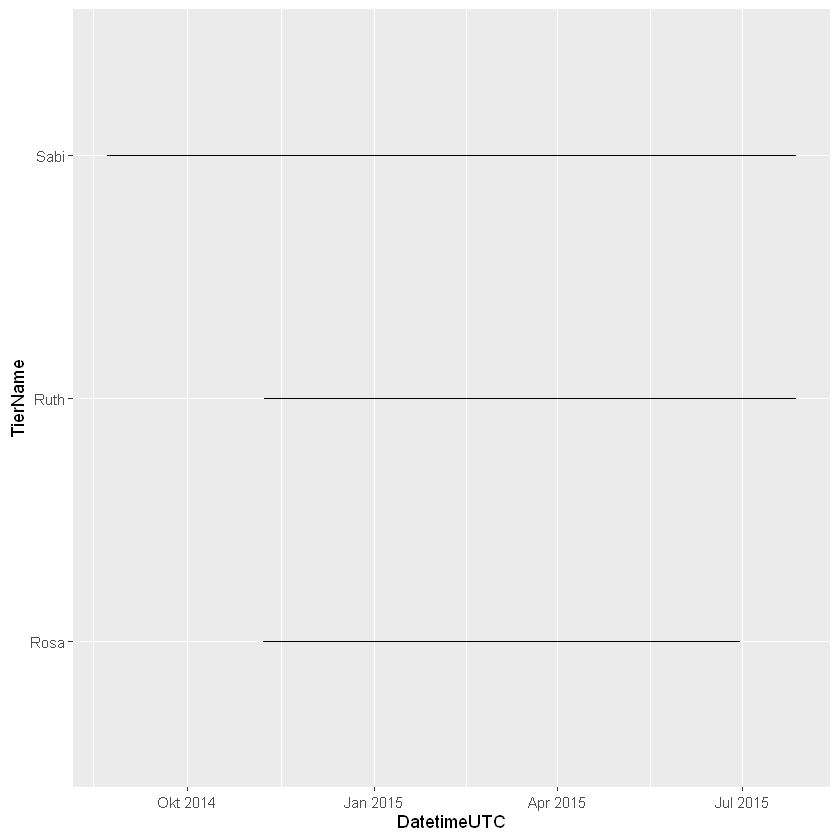

In [38]:
library(tidyverse)

ggplot(wildschwein_BE, aes(x= DatetimeUTC, y = TierName)) +
geom_line()

### What is the temporal sampling interval between the locations?

In [39]:
paste("Im Durchschnitt", round(mean(wildschwein_BE$timelag, na.rm = TRUE)/60, 0), "Minuten")

paste("Im Median", round(median(wildschwein_BE$timelag, na.rm = TRUE)/60, 0), "Minuten")

[1] "Im Durchschnitt 23 Minuten"

[1] "Im Median 15 Minuten"

### Distance between locations
Similar to how we calculated the timelag between subsequent locations, we can calculate the **distance** like so:

In [40]:
later <- lead(wildschwein_BE$geometry)
now <- wildschwein_BE$geometry

distance <- st_distance(later, now, by_element = TRUE)  # by_element must be set to TRUE
distance[1:10]

Units: [m]
 [1] 111.107991  38.239518  16.776044  10.784083   7.401552   6.221583
 [7]  11.309834 115.076367 142.239683  11.926842

However, similar to `difftime()`, the output has a unit which complicates things. Therefore, it’s simpler to wrap the output in `as.numeric()`. Let’s make a function for this process:

In [41]:
distance_by_element <- function(later, now){
  as.numeric(
    st_distance(later, now, by_element = TRUE)
  )
}

Use this function to create a new column named steplength with the distance between locations.

In [42]:
wildschwein_BE$steplength <- distance_by_element(later, now)
head(wildschwein_BE)

TierID,TierName,CollarID,DatetimeUTC,geometry,timelag,steplength
<chr>,<chr>,<dbl>,<dttm>,<POINT [m]>,<dbl>,<dbl>
002A,Sabi,12275,2014-08-22 21:00:12,POINT (2570409 1204752),904,111.107991
002A,Sabi,12275,2014-08-22 21:15:16,POINT (2570402 1204863),927,38.239518
002A,Sabi,12275,2014-08-22 21:30:43,POINT (2570394 1204826),924,16.776044
002A,Sabi,12275,2014-08-22 21:46:07,POINT (2570379 1204817),855,10.784083
002A,Sabi,12275,2014-08-22 22:00:22,POINT (2570390 1204818),888,7.401552
002A,Sabi,12275,2014-08-22 22:15:10,POINT (2570390 1204825),903,6.221583


### Deriving speed
Calculate the animals’ **speed** based on steplength and the timelag (from the last task).

In [43]:
wildschwein_BE$speed <- round(wildschwein_BE$steplength/wildschwein_BE$timelag, 4)
head(wildschwein_BE)

TierID,TierName,CollarID,DatetimeUTC,geometry,timelag,steplength,speed
<chr>,<chr>,<dbl>,<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>
002A,Sabi,12275,2014-08-22 21:00:12,POINT (2570409 1204752),904,111.107991,0.1229
002A,Sabi,12275,2014-08-22 21:15:16,POINT (2570402 1204863),927,38.239518,0.0413
002A,Sabi,12275,2014-08-22 21:30:43,POINT (2570394 1204826),924,16.776044,0.0182
002A,Sabi,12275,2014-08-22 21:46:07,POINT (2570379 1204817),855,10.784083,0.0126
002A,Sabi,12275,2014-08-22 22:00:22,POINT (2570390 1204818),888,7.401552,0.0083
002A,Sabi,12275,2014-08-22 22:15:10,POINT (2570390 1204825),903,6.221583,0.0069


### Visualize / Plausibility Check
It’s important to repeatedly **visualize our results**, to make sure these are plausible. This is much simpler if we just look at a small sample of our dataset. We can use head(100) to extract the first 100 rows.

In [44]:
wildschwein_sample <- wildschwein_BE %>%
  filter(TierName == "Sabi") %>%
  head(100)

In [45]:
library(tmap)
tmap_mode("view")

m <- tm_shape(wildschwein_sample) + 
  tm_dots()

ℹ tmap modes "plot" - "view"
ℹ toggle with `tmap::ttm()`
This message is displayed once per session.


In [ ]:
print(tmap_leaflet(m))
tmap_save(m, "Week_2_Karte.html")

### From Points to Lines

The wild boar move continuously through space, but our samples are discrete points. It would be helpful to at least see the **sequence of these samples**. We can do this by casting our points to **lines**. However, we first need to dissolve our single points into a MULTIPOINT object, just like we had to do in the first week when we calculated the minimum convex polygon per animal (see Input: Calculate Convex Hull). The option `do_union = FALSE` is a confusing way to preserve the order of the points, see Nils’ question on GitHub.

In addition, we can set OpenStreetMap to be the default basemap, since it’s available at lower zoom levels.

In [46]:
wildschwein_sample_line <- wildschwein_sample %>% 
  # dissolve to a MULTIPOINT:
  summarise(do_union = FALSE) %>%
  st_cast("LINESTRING")

In [47]:
wildschwein_sample_line

TierID,geometry
<chr>,<LINESTRING [m]>
002A,LINESTRING (2570409 1204752...


In [48]:
m <- tm_shape(wildschwein_sample_line) +
  tm_lines() +
  tm_shape(wildschwein_sample) + 
  tm_dots()

print(tmap_leaflet(m))
tmap_save(m, "Week_2_Karte_Linie.html")

Interactive map saved to C:\Users\vikto\1 MeinJupyter\1 Master\Patterns & Trends\Week_2_Karte_Linie.html



## Exercise B

In preparation, you’ve read the paper by Laube and Purves (2011). In this paper, the authors **analyse speed at different scales and compare these different values**. Let’s conceptually reconstruct one of the experiments the authors conducted.

The figure shows how speed was calculated in the first of three scales. Do you notice how their method differs to how we calculated speed? We calculated the speed for a specific sample to be the distance travelled to the next sample devided by the according time difference. Laube and Purves (2011) use the distance travelled from the previous sample to the next sample (and the according time difference).

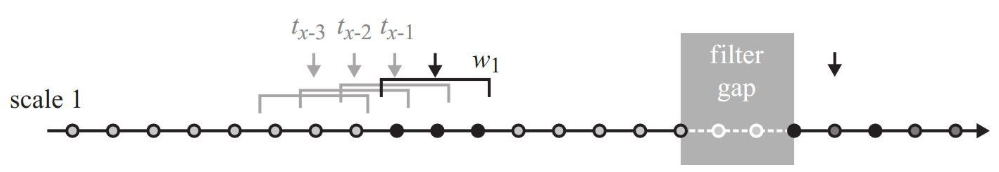

In [49]:
library(IRdisplay)
display_png(file = "Data/Screenshot 2026-04-23 092330.png", width = 800)

To reproduce this experiment, we will use a new wild boar dataset with following characteristics:

- Small number of samples (200 locations)
- Only one individual (Caro)
- A constant sampling interval (60s)
  
This last aspect is important, since we would otherwise have to deal with varying sampling intervals, which would greatly complicate things. Download this dataset from moodle (caro60.csv). Import it just like you imported the other wild boar data and save it to a new variable named caro (note that the locations are stored in EPSG 2056).

We will need the following two functions from Exercise A:

In [50]:
library("readr")
library("sf")
library("dplyr")

difftime_secs <- function(later, now){
    as.numeric(difftime(later, now, units = "secs"))
}

distance_by_element <- function(later, now){
  as.numeric(
    st_distance(later, now, by_element = TRUE)
  )
}

### Import Data
We can then import the data. We can **discard all columns with the exception of DatetimeUTC** with `select` (see below).

In [51]:
caro <- read_delim("Data/caro60.csv", ",") %>%
  st_as_sf(coords = c("E","N"), crs = 2056) %>%
  select(DatetimeUTC)

Rows: 200 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [52]:
head(caro)

DatetimeUTC,geometry
<dttm>,<POINT [m]>
2015-09-15 08:07:00,POINT (2570589 1205095)
2015-09-15 08:08:00,POINT (2570573 1205096)
2015-09-15 08:09:00,POINT (2570536 1205099)
2015-09-15 08:10:00,POINT (2570518 1205115)
2015-09-15 08:11:00,POINT (2570499 1205130)
2015-09-15 08:12:00,POINT (2570489 1205130)


### Calculate speed at scale 1
In our first scale, we will assume a **sampling window of 120 seconds**. This conveniently means that for every location, you can use the previous and next location to calculate speed. Try to implement this in R.

In [53]:
now = lag(caro$DatetimeUTC)
later = lead(caro$DatetimeUTC)

In [54]:
now[1:10]

 [1] NA                        "2015-09-15 08:07:00 UTC"
 [3] "2015-09-15 08:08:00 UTC" "2015-09-15 08:09:00 UTC"
 [5] "2015-09-15 08:10:00 UTC" "2015-09-15 08:11:00 UTC"
 [7] "2015-09-15 08:12:00 UTC" "2015-09-15 08:13:00 UTC"
 [9] "2015-09-15 08:14:00 UTC" "2015-09-15 08:15:00 UTC"

In [55]:
later[1:10]

 [1] "2015-09-15 08:08:00 UTC" "2015-09-15 08:09:00 UTC"
 [3] "2015-09-15 08:10:00 UTC" "2015-09-15 08:11:00 UTC"
 [5] "2015-09-15 08:12:00 UTC" "2015-09-15 08:13:00 UTC"
 [7] "2015-09-15 08:14:00 UTC" "2015-09-15 08:15:00 UTC"
 [9] "2015-09-15 08:16:00 UTC" "2015-09-15 08:17:00 UTC"

In [56]:
caro <- mutate(caro, 
               timelag = difftime_secs(later, now))

In [57]:
head(caro)

DatetimeUTC,geometry,timelag
<dttm>,<POINT [m]>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA
2015-09-15 08:08:00,POINT (2570573 1205096),120
2015-09-15 08:09:00,POINT (2570536 1205099),120
2015-09-15 08:10:00,POINT (2570518 1205115),120
2015-09-15 08:11:00,POINT (2570499 1205130),120
2015-09-15 08:12:00,POINT (2570489 1205130),120


In [58]:
now = lag(caro$geometry)
later = lead(caro$geometry)

In [59]:
now[1:10]
later[1:10]

POINT EMPTY

POINT (2570589 1205095)

POINT (2570573 1205096)

POINT (2570536 1205099)

POINT (2570518 1205115)



Geometry set for 10 features  (with 1 geometry empty)
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 2570481 ymin: 1205095 xmax: 2570589 ymax: 1205130
Projected CRS: CH1903+ / LV95
First 5 geometries:

POINT (2570573 1205096)

POINT (2570536 1205099)

POINT (2570518 1205115)

POINT (2570499 1205130)

POINT (2570489 1205130)



Geometry set for 10 features 
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 2570481 ymin: 1205091 xmax: 2570573 ymax: 1205130
Projected CRS: CH1903+ / LV95
First 5 geometries:

In [60]:
caro <- mutate(caro, 
               steplength = round(distance_by_element(later, now), 1))

In [61]:
head(caro)

DatetimeUTC,geometry,timelag,steplength
<dttm>,<POINT [m]>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0


In [62]:
caro <- mutate(caro, 
               speed = round(steplength/timelag, 3))

In [63]:
head(caro)

DatetimeUTC,geometry,timelag,steplength,speed
<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4,0.437
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4,0.487
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2,0.410
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6,0.272
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0,0.150


### Calculate speed at scale 2
To compare the effect of different sampling intervals, Laube and Purves (2011) calculated speed at different scales (i.e. different sampling windows $w$).

In the previous task, we assumed a $w = 120$. In this task, try to implement $w = 240$ (see Figure 8.2), which means using an **offset of 2**.

- Tip: Use the `n = parameter` in `lead/lag` to increase the offset.
- Store values **timelag, steplength and speed** in the columns `timelag2`, `steplength2` and `speed2` to distinguish them from the values from scale 1

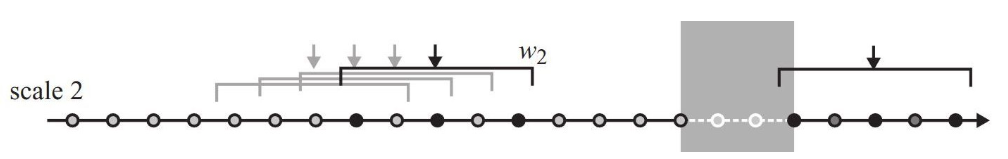

In [64]:
display_png(file = "Data/fig2.png", width = 800)

In [65]:
head(caro)

DatetimeUTC,geometry,timelag,steplength,speed
<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4,0.437
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4,0.487
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2,0.410
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6,0.272
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0,0.150


In [66]:
now = lag(caro$DatetimeUTC, n=2)
later = lead(caro$DatetimeUTC, n=2)

In [67]:
now[1:10]

 [1] NA                        NA                       
 [3] "2015-09-15 08:07:00 UTC" "2015-09-15 08:08:00 UTC"
 [5] "2015-09-15 08:09:00 UTC" "2015-09-15 08:10:00 UTC"
 [7] "2015-09-15 08:11:00 UTC" "2015-09-15 08:12:00 UTC"
 [9] "2015-09-15 08:13:00 UTC" "2015-09-15 08:14:00 UTC"

In [68]:
later[1:10]

 [1] "2015-09-15 08:09:00 UTC" "2015-09-15 08:10:00 UTC"
 [3] "2015-09-15 08:11:00 UTC" "2015-09-15 08:12:00 UTC"
 [5] "2015-09-15 08:13:00 UTC" "2015-09-15 08:14:00 UTC"
 [7] "2015-09-15 08:15:00 UTC" "2015-09-15 08:16:00 UTC"
 [9] "2015-09-15 08:17:00 UTC" "2015-09-15 08:18:00 UTC"

In [69]:
caro <- mutate(caro, 
               timelag2 = difftime_secs(later, now))

In [70]:
head(caro)

DatetimeUTC,geometry,timelag,steplength,speed,timelag2
<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA,NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4,0.437,NA
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4,0.487,240
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2,0.410,240
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6,0.272,240
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0,0.150,240


In [71]:
now = lag(caro$geometry, n=2)
later = lead(caro$geometry, n=2)

In [72]:
now[1:10]
later[1:10]

POINT EMPTY

POINT EMPTY

POINT (2570589 1205095)

POINT (2570573 1205096)

POINT (2570536 1205099)



Geometry set for 10 features  (with 2 geometries empty)
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 2570481 ymin: 1205095 xmax: 2570589 ymax: 1205130
Projected CRS: CH1903+ / LV95
First 5 geometries:

POINT (2570536 1205099)

POINT (2570518 1205115)

POINT (2570499 1205130)

POINT (2570489 1205130)

POINT (2570482 1205124)



Geometry set for 10 features 
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 2570481 ymin: 1205089 xmax: 2570536 ymax: 1205130
Projected CRS: CH1903+ / LV95
First 5 geometries:

In [73]:
caro <- mutate(caro, 
               steplength2 = round(distance_by_element(later, now), 1))

In [74]:
caro <- mutate(caro, 
               speed2 = round(steplength2/timelag2, 3))

In [75]:
head(caro)

DatetimeUTC,geometry,timelag,steplength,speed,timelag2,steplength2,speed2
<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA,NA,NA,NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4,0.437,NA,NA,NA
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4,0.487,240,96.5,0.402
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2,0.410,240,90.8,0.378
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6,0.272,240,59.6,0.248
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0,0.150,240,37.3,0.155


### Calculate speed at scale 3
Redo the previous task with $w = 480s$  (offset of n = 4)

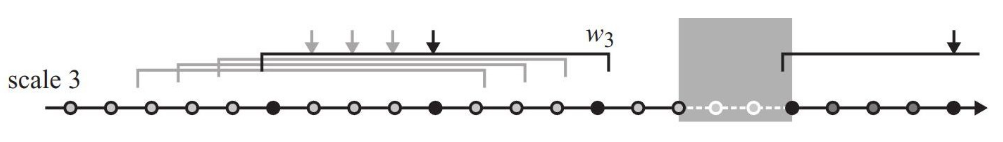

In [76]:
display_png(file = "Data/laube3.png", width = 800)

In [77]:
now = lag(caro$DatetimeUTC, n=4)
later = lead(caro$DatetimeUTC, n=4)

In [78]:
caro <- mutate(caro, 
               timelag3 = difftime_secs(later, now))

In [79]:
now = lag(caro$geometry, n=4)
later = lead(caro$geometry, n=4)

In [80]:
caro <- mutate(caro, 
               steplength3 = round(distance_by_element(later, now), 1))

In [81]:
caro <- mutate(caro, 
               speed3 = round(steplength3/timelag3, 3))

In [82]:
head(caro)

DatetimeUTC,geometry,timelag,steplength,speed,timelag2,steplength2,speed2,timelag3,steplength3,speed3
<dttm>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,POINT (2570589 1205095),NA,NA,NA,NA,NA,NA,NA,NA,NA
2015-09-15 08:08:00,POINT (2570573 1205096),120,52.4,0.437,NA,NA,NA,NA,NA,NA
2015-09-15 08:09:00,POINT (2570536 1205099),120,58.4,0.487,240,96.5,0.402,NA,NA,NA
2015-09-15 08:10:00,POINT (2570518 1205115),120,49.2,0.410,240,90.8,0.378,NA,NA,NA
2015-09-15 08:11:00,POINT (2570499 1205130),120,32.6,0.272,240,59.6,0.248,480,102.5,0.214
2015-09-15 08:12:00,POINT (2570489 1205130),120,18.0,0.150,240,37.3,0.155,480,82.5,0.172


### Compare speed across scales
We now have a dataframe with three different speed values per sample, corresponding to the different scales / sampling windows ($w1 = 120s, w2 = 240s, w3 = 480s$). It would now be interesting to compare these measurements and see our results correspond to those of Laube and Purves (2011). In their experiments, the authors observe:

- A steady decrease in median speed as the temporal analysis scale increases;
- A decrease in the overall variance in speed as the temporal scale increases;
- Lower minimum values at the shortest temporal scales;

The authors visualize these observations using box plots. To to the same, we need to process our data slightly. Currently, our data looks like this:

In [83]:
head(caro |> 
  st_drop_geometry() |> 
  select(DatetimeUTC, speed, speed2, speed3))

DatetimeUTC,speed,speed2,speed3
<dttm>,<dbl>,<dbl>,<dbl>
2015-09-15 08:07:00,NA,NA,NA
2015-09-15 08:08:00,0.437,NA,NA
2015-09-15 08:09:00,0.487,0.402,NA
2015-09-15 08:10:00,0.410,0.378,NA
2015-09-15 08:11:00,0.272,0.248,0.214
2015-09-15 08:12:00,0.150,0.155,0.172


We can make a box plot of a single column using ggplot2:

Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`)."


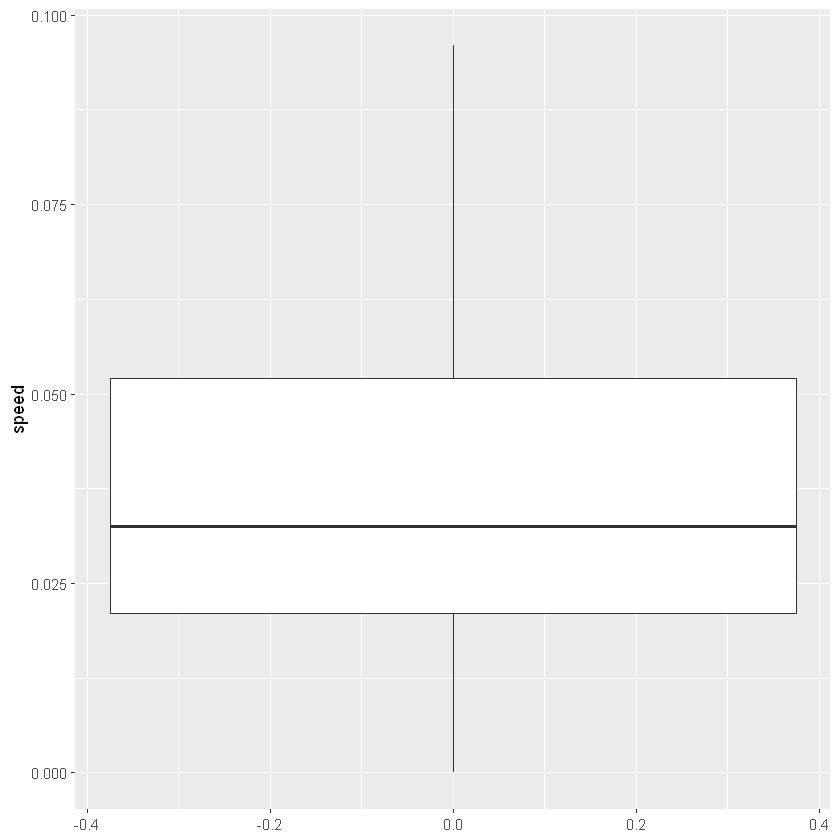

In [84]:
library(ggplot2)

ggplot(caro, aes(y = speed)) + 
    # we remove outliers to increase legibility, analogue
  # Laube and Purves (2011)
  geom_boxplot(outliers = FALSE)

However, if we want to **compare speed with speed2 and speed3**, we need need a ***long table*** rather than wide one (which is what we currently have). To make our table long, we can use the function `pivot_longer` from tidyr:

In [85]:
library(tidyr)

# before pivoting, let's simplify our data.frame
caro2 <- caro |> 
  st_drop_geometry() |> 
  select(DatetimeUTC, speed, speed2, speed3)

caro_long <- caro2 |> 
  pivot_longer(c(speed, speed2, speed3))
  
head(caro_long)

DatetimeUTC,name,value
<dttm>,<chr>,<dbl>
2015-09-15 08:07:00,speed,NA
2015-09-15 08:07:00,speed2,NA
2015-09-15 08:07:00,speed3,NA
2015-09-15 08:08:00,speed,0.437
2015-09-15 08:08:00,speed2,NA
2015-09-15 08:08:00,speed3,NA


Warning message:
"Removed 14 rows containing non-finite outside the scale range (`stat_boxplot()`)."


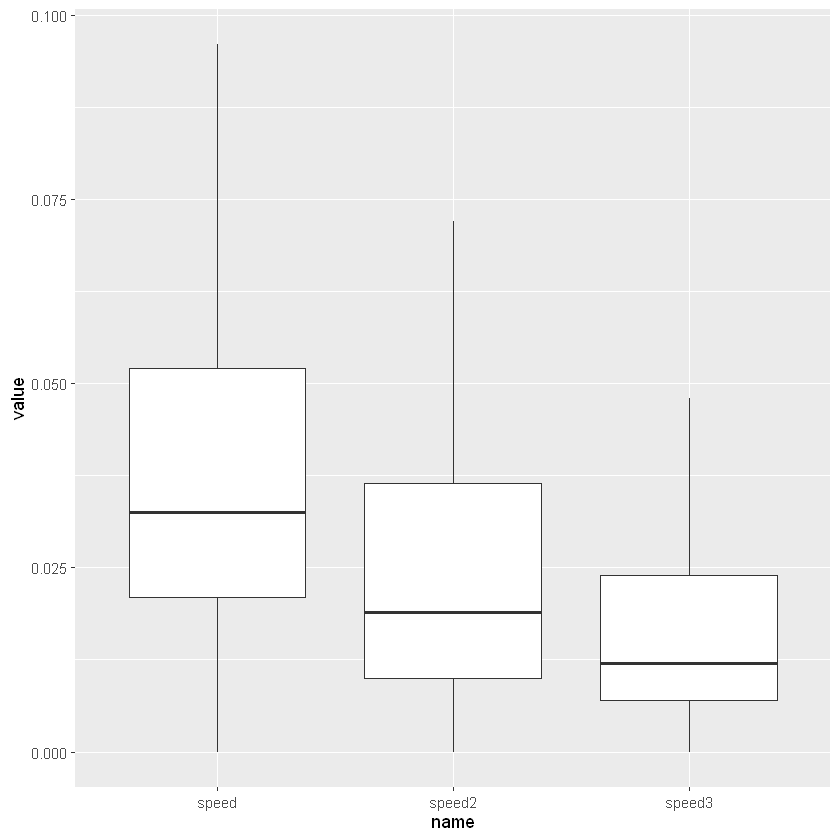

In [86]:
ggplot(caro_long, aes(name, value)) +
  # we remove outliers to increase legibility, analogue
  # Laube and Purves (2011)
  geom_boxplot(outliers = FALSE)

## Exercise C

In the semester project, you will analyse your own movement data, collected with an app of your choice or the GPS tracker. **Acquire this data and save it to a subfolder of your current R Project named `data`**.

Now, import your data in the same way you imported the the wild boar data in task 1. Next, start exploring your data, similarly as you did in task 2. At a minimum:

- Import your data as a data frame and convert it to an sf object, using the correct CRS information
- Convert your data to CH1903+ LV95
- Make a map of your data using ggplot2 or tmap.

In [ ]:
library("readr")
library("sf")

data <- read_delim("Data/Geolife Trajectories 1.3/Geolife Trajectories 1.3//Data//001//Trajectory//20081023055305.plt")

head(data)

In [ ]:
wildschwein_BE <- st_as_sf(wildschwein_BE, coords = c("E", "N"), crs = 2056)